# PTB-XL — Exploratory Data Analysis
**DAT255 Project** — Edvard Vindenes Steenslid & Morten Kvamme

This notebook performs a thorough exploration of the PTB-XL dataset **before** any modelling, so we can make informed decisions about preprocessing, class weighting, and architecture design.

---

### What we're looking for
1. **Label imbalance** — how skewed are the five superclasses?
2. **Multi-label co-occurrence** — which conditions appear together?
3. **Demographics** — age/sex distributions and their relationship to diagnoses
4. **Signal quality** — noise, missing values, amplitude ranges
5. **Fold balance** — is the stratified split actually balanced?
6. **Waveform statistics** — per-lead distributions that inform normalisation

## 1. Setup

In [1]:
!pip install -q wfdb pandas numpy matplotlib seaborn scikit-learn
# The dataset can be found here: https://physionet.org/content/ptb-xl/1.0.3/ and must be downloaded separately.
# The zip file should be placed in the same directory as this notebook
# and named "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
import os
import ast
import zipfile
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from sklearn.preprocessing import MultiLabelBinarizer

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

## 2. Load the Dataset

In [5]:
ZIP_PATH = "./ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip"
DATA_DIR = "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3"

if not os.path.isdir(DATA_DIR):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(".")
    print("Done.")
else:
    print(f"Dataset already extracted: {DATA_DIR}")

print("Contents:", os.listdir(DATA_DIR))

Extracting dataset...
Done.
Contents: ['example_physionet.py', 'LICENSE.txt', 'ptbxl_database.csv', 'ptbxl_v102_changelog.txt', 'ptbxl_v103_changelog.txt', 'RECORDS', 'records100', 'records500', 'scp_statements.csv', 'SHA256SUMS.txt']


In [6]:
# ── Load metadata ──────────────────────────────────────────────────
df = pd.read_csv(os.path.join(DATA_DIR, "ptbxl_database.csv"), index_col="ecg_id")
df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

print(f"Total records      : {len(df)}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes.to_string())

Total records      : 21799
Columns (27): ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

Data types:
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            float64
device                              str
recording_date                      str
report                              str
scp_codes                        object
heart_axis                          str
infarction_stadium1                 str
infarction_stadiu

In [9]:
# ── Quick look at the raw table ────────────────────────────────────
df.head(10)

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr
6,19005.0,18.0,1,NaN,58.0,2.0,0.0,CS-12 E,1984-11-28 13:32:13,sinusrhythmus normales ekg,...,True,", V1",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00006_lr,records500/00000/00006_hr
7,16193.0,54.0,0,NaN,83.0,2.0,0.0,CS-12 E,1984-11-28 13:32:22,"sinusrhythmus linkstyp t abnormal, wahrscheinl...",...,True,NaN,NaN,NaN,NaN,NaN,NaN,7,records100/00000/00007_lr,records500/00000/00007_hr
8,11275.0,48.0,0,NaN,95.0,2.0,0.0,CS-12 E,1984-12-01 14:49:52,sinusrhythmus linkstyp qrs(t) abnormal infe...,...,True,", II,AVF",", I-AVF,",NaN,NaN,NaN,NaN,9,records100/00000/00008_lr,records500/00000/00008_hr
9,18792.0,55.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-12-08 09:44:43,sinusrhythmus normales ekg,...,True,NaN,", I-AVR,",NaN,NaN,NaN,NaN,10,records100/00000/00009_lr,records500/00000/00009_hr


In [10]:
# ── Missing values ─────────────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print("Columns with missing values:")
    for col, count in missing.items():
        print(f"  {col:25s}: {count:6d}  ({count/len(df)*100:.1f}%)")
else:
    print("No missing values in metadata.")

Columns with missing values:
  electrodes_problems      :  21769  (99.9%)
  infarction_stadium2      :  21696  (99.5%)
  pacemaker                :  21508  (98.7%)
  burst_noise              :  21186  (97.2%)
  baseline_drift           :  20201  (92.7%)
  extra_beats              :  19850  (91.1%)
  static_noise             :  18539  (85.0%)
  infarction_stadium1      :  16187  (74.3%)
  height                   :  14825  (68.0%)
  weight                   :  12378  (56.8%)
  validated_by             :   9378  (43.0%)
  heart_axis               :   8468  (38.8%)
  nurse                    :   1473  (6.8%)
  site                     :     17  (0.1%)


## 3. SCP Code Analysis (All Annotation Levels)

In [11]:
# ── Load the SCP statements lookup table ───────────────────────────
scp_df = pd.read_csv(os.path.join(DATA_DIR, "scp_statements.csv"), index_col=0)

print(f"Total SCP statements: {len(scp_df)}")
print(f"\nColumns: {list(scp_df.columns)}")
print(f"\nStatement categories:")
for col in ["diagnostic", "form", "rhythm"]:
    if col in scp_df.columns:
        print(f"  {col}: {scp_df[col].sum():.0f} codes")

scp_df.head(10)

Total SCP statements: 71

Columns: ['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']

Statement categories:
  diagnostic: 44 codes
  form: 19 codes
  rhythm: 12 codes


,description,diagnostic,form,rhythm,diagnostic_class,diagnostic_subclass,Statement Category,SCP-ECG Statement Description,AHA code,aECG REFID,CDISC Code,DICOM Code
NDT,non-diagnostic T abnormalities,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,non-diagnostic T abnormalities,NaN,NaN,NaN,NaN
NST_,non-specific ST changes,1.0,1.0,NaN,STTC,NST_,Basic roots for coding ST-T changes and abnorm...,non-specific ST changes,145.0,MDC_ECG_RHY_STHILOST,NaN,NaN
DIG,digitalis-effect,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,suggests digitalis-effect,205.0,NaN,NaN,NaN
LNGQT,long QT-interval,1.0,1.0,NaN,STTC,STTC,other ST-T descriptive statements,long QT-interval,148.0,NaN,NaN,NaN
NORM,normal ECG,1.0,NaN,NaN,NORM,NORM,Normal/abnormal,normal ECG,1.0,NaN,NaN,F-000B7
IMI,inferior myocardial infarction,1.0,NaN,NaN,MI,IMI,Myocardial Infarction,inferior myocardial infarction,161.0,NaN,NaN,NaN
ASMI,anteroseptal myocardial infarction,1.0,NaN,NaN,MI,AMI,Myocardial Infarction,anteroseptal myocardial infarction,165.0,NaN,NaN,NaN
LVH,left ventricular hypertrophy,1.0,NaN,NaN,HYP,LVH,Ventricular Hypertrophy,left ventricular hypertrophy,142.0,NaN,C71076,NaN
LAFB,left anterior fascicular block,1.0,NaN,NaN,CD,LAFB/LPFB,Intraventricular and intra-atrial Conduction d...,left anterior fascicular block,101.0,MDC_ECG_BEAT_BLK_ANT_L_HEMI,C62267,D3-33140
ISC_,non-specific ischemic,1.0,NaN,NaN,STTC,ISC_,Basic roots for coding ST-T changes and abnorm...,ischemic ST-T changes,226.0,NaN,NaN,NaN


In [12]:
# ── Diagnostic codes only ──────────────────────────────────────────
diag_df = scp_df[scp_df["diagnostic"] == 1].copy()
code_to_superclass = diag_df["diagnostic_class"].to_dict()
code_to_subclass = diag_df["diagnostic_subclass"].to_dict()

print(f"Diagnostic codes: {len(diag_df)}")
print(f"\nSuperclass mapping:")
for sc in sorted(diag_df["diagnostic_class"].dropna().unique()):
    codes = diag_df[diag_df["diagnostic_class"] == sc].index.tolist()
    print(f"  {sc:5s}: {len(codes):2d} codes — {codes}")

Diagnostic codes: 44

Superclass mapping:
  CD   : 11 codes — ['LAFB', 'IRBBB', '1AVB', 'IVCD', 'CRBBB', 'CLBBB', 'LPFB', 'WPW', 'ILBBB', '3AVB', '2AVB']
  HYP  :  5 codes — ['LVH', 'LAO/LAE', 'RVH', 'RAO/RAE', 'SEHYP']
  MI   : 14 codes — ['IMI', 'ASMI', 'ILMI', 'AMI', 'ALMI', 'INJAS', 'LMI', 'INJAL', 'IPLMI', 'IPMI', 'INJIN', 'INJLA', 'PMI', 'INJIL']
  NORM :  1 codes — ['NORM']
  STTC : 13 codes — ['NDT', 'NST_', 'DIG', 'LNGQT', 'ISC_', 'ISCAL', 'ISCIN', 'ISCIL', 'ISCAS', 'ISCLA', 'ANEUR', 'EL', 'ISCAN']


In [13]:
# ── Frequency of every individual SCP code across the dataset ──────
all_codes = []
for scp_dict in df["scp_codes"]:
    for code, likelihood in scp_dict.items():
        if likelihood >= 50:  # PTB-XL convention
            all_codes.append(code)

code_counts = Counter(all_codes)
code_freq = pd.DataFrame(
    code_counts.most_common(),
    columns=["scp_code", "count"]
)
code_freq["pct"] = (code_freq["count"] / len(df) * 100).round(1)

# Add description from lookup table
code_freq["description"] = code_freq["scp_code"].map(
    scp_df["description"].to_dict() if "description" in scp_df.columns
    else {}
)
code_freq["superclass"] = code_freq["scp_code"].map(code_to_superclass)

print(f"Total unique SCP codes found: {len(code_freq)}")
print(f"\nTop 25 most frequent codes:")
code_freq.head(25)

Total unique SCP codes found: 52

Top 25 most frequent codes:


,scp_code,count,pct,description,superclass
0,NORM,9438,43.3,normal ECG,NORM
1,ASMI,2007,9.2,anteroseptal myocardial infarction,MI
2,NDT,1824,8.4,non-diagnostic T abnormalities,STTC
3,LVH,1751,8.0,left ventricular hypertrophy,HYP
4,IMI,1714,7.9,inferior myocardial infarction,MI
5,LAFB,1622,7.4,left anterior fascicular block,CD
6,ISC_,1260,5.8,non-specific ischemic,STTC
7,IRBBB,1115,5.1,incomplete right bundle branch block,CD
8,PVC,1027,4.7,ventricular premature complex,NaN
9,1AVB,790,3.6,first degree AV block,CD


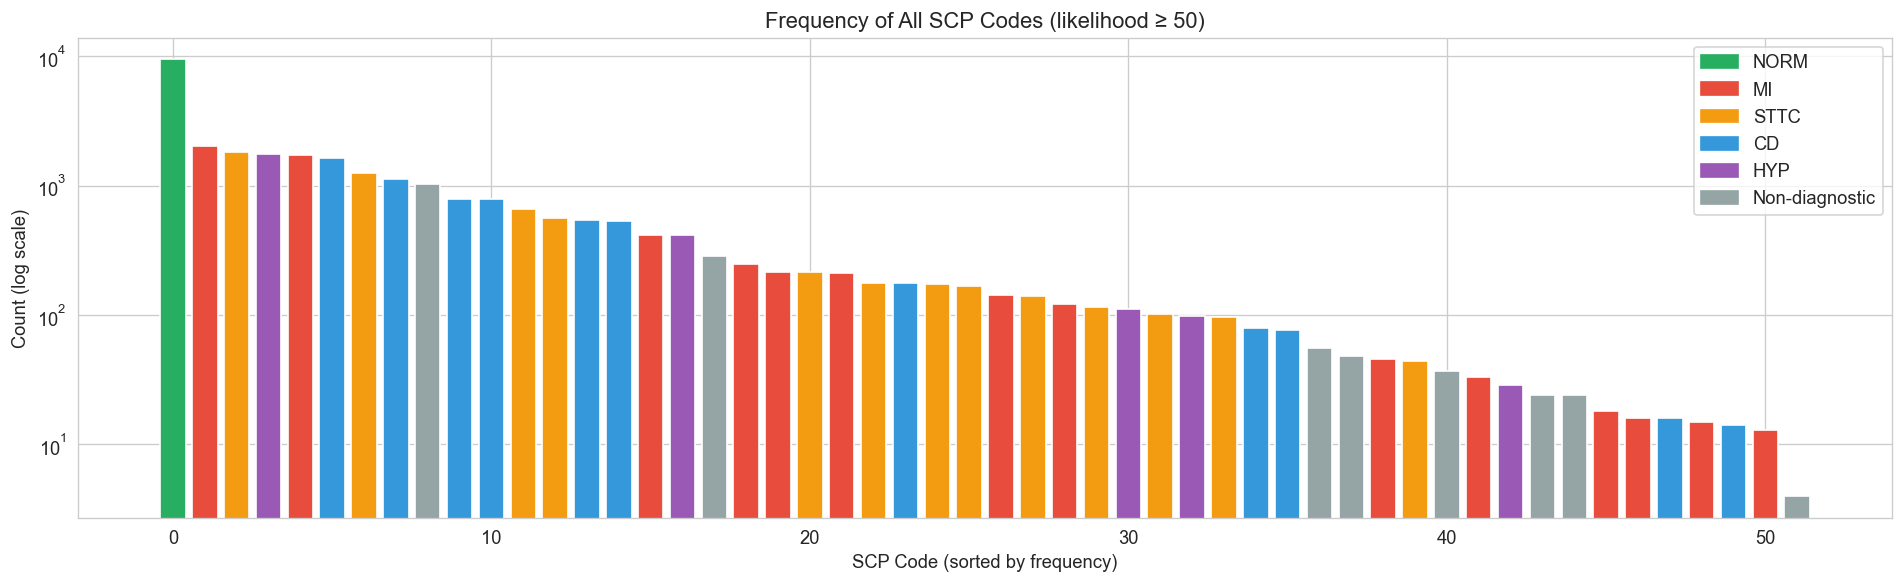


Most common code: NORM (9438 occurrences)
Rarest code:      STACH (4 occurrences)
Codes appearing < 50 times: 15 / 52


In [14]:
# ── Plot all code frequencies (log scale) ──────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
colors = code_freq["superclass"].map({
    "NORM": "#27ae60", "MI": "#e74c3c", "STTC": "#f39c12",
    "CD": "#3498db", "HYP": "#9b59b6"
}).fillna("#95a5a6")  # grey for non-diagnostic

ax.bar(range(len(code_freq)), code_freq["count"], color=colors)
ax.set_yscale("log")
ax.set_xlabel("SCP Code (sorted by frequency)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Frequency of All SCP Codes (likelihood ≥ 50)")

# Legend
from matplotlib.patches import Patch
legend_items = [
    Patch(color="#27ae60", label="NORM"),
    Patch(color="#e74c3c", label="MI"),
    Patch(color="#f39c12", label="STTC"),
    Patch(color="#3498db", label="CD"),
    Patch(color="#9b59b6", label="HYP"),
    Patch(color="#95a5a6", label="Non-diagnostic"),
]
ax.legend(handles=legend_items, loc="upper right")
plt.tight_layout()
plt.savefig("scp_code_frequencies.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMost common code: {code_freq.iloc[0]['scp_code']} "
      f"({code_freq.iloc[0]['count']} occurrences)")
print(f"Rarest code:      {code_freq.iloc[-1]['scp_code']} "
      f"({code_freq.iloc[-1]['count']} occurrences)")
print(f"Codes appearing < 50 times: "
      f"{(code_freq['count'] < 50).sum()} / {len(code_freq)}")

## 4. Superclass Label Distribution & Imbalance

In [15]:
# ── Map records to diagnostic superclasses ─────────────────────────
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]

def extract_superclasses(scp_dict):
    classes = set()
    for code, likelihood in scp_dict.items():
        if code in code_to_superclass and likelihood >= 50:
            sc = code_to_superclass[code]
            if sc in SUPERCLASSES:
                classes.add(sc)
    return classes

df["superclasses"] = df["scp_codes"].apply(extract_superclasses)
df["n_superclasses"] = df["superclasses"].apply(len)

# Binarize
mlb = MultiLabelBinarizer(classes=SUPERCLASSES)
labels = mlb.fit_transform(df["superclasses"])
for i, sc in enumerate(SUPERCLASSES):
    df[sc] = labels[:, i]

# Records with at least one diagnostic label
df_diag = df[df["n_superclasses"] > 0].copy()
labels_diag = labels[df["n_superclasses"] > 0]

print(f"Records with ≥1 diagnostic superclass: {len(df_diag)} / {len(df)}")
print(f"Records with NO diagnostic superclass : {len(df) - len(df_diag)}")

Records with ≥1 diagnostic superclass: 20373 / 21799
Records with NO diagnostic superclass : 1426


In [16]:
# ── Class counts & imbalance ratios ────────────────────────────────
counts = labels_diag.sum(axis=0)
total = len(labels_diag)

imbalance_df = pd.DataFrame({
    "superclass": SUPERCLASSES,
    "positive": counts.astype(int),
    "negative": (total - counts).astype(int),
    "prevalence_pct": (counts / total * 100).round(1),
    "neg_pos_ratio": ((total - counts) / counts).round(2),
})

# Imbalance ratio: largest class / smallest class
max_class = counts.max()
min_class = counts.min()
print(f"Most  common class: {SUPERCLASSES[counts.argmax()]} ({int(max_class)})")
print(f"Least common class: {SUPERCLASSES[counts.argmin()]} ({int(min_class)})")
print(f"Imbalance ratio (max/min): {max_class/min_class:.1f}x")
print()
imbalance_df

Most  common class: NORM (9438)
Least common class: HYP (2258)
Imbalance ratio (max/min): 4.2x



,superclass,positive,negative,prevalence_pct,neg_pos_ratio
0,NORM,9438,10935,46.3,1.16
1,MI,4134,16239,20.3,3.93
2,STTC,5078,15295,24.9,3.01
3,CD,4891,15482,24.0,3.17
4,HYP,2258,18115,11.1,8.02


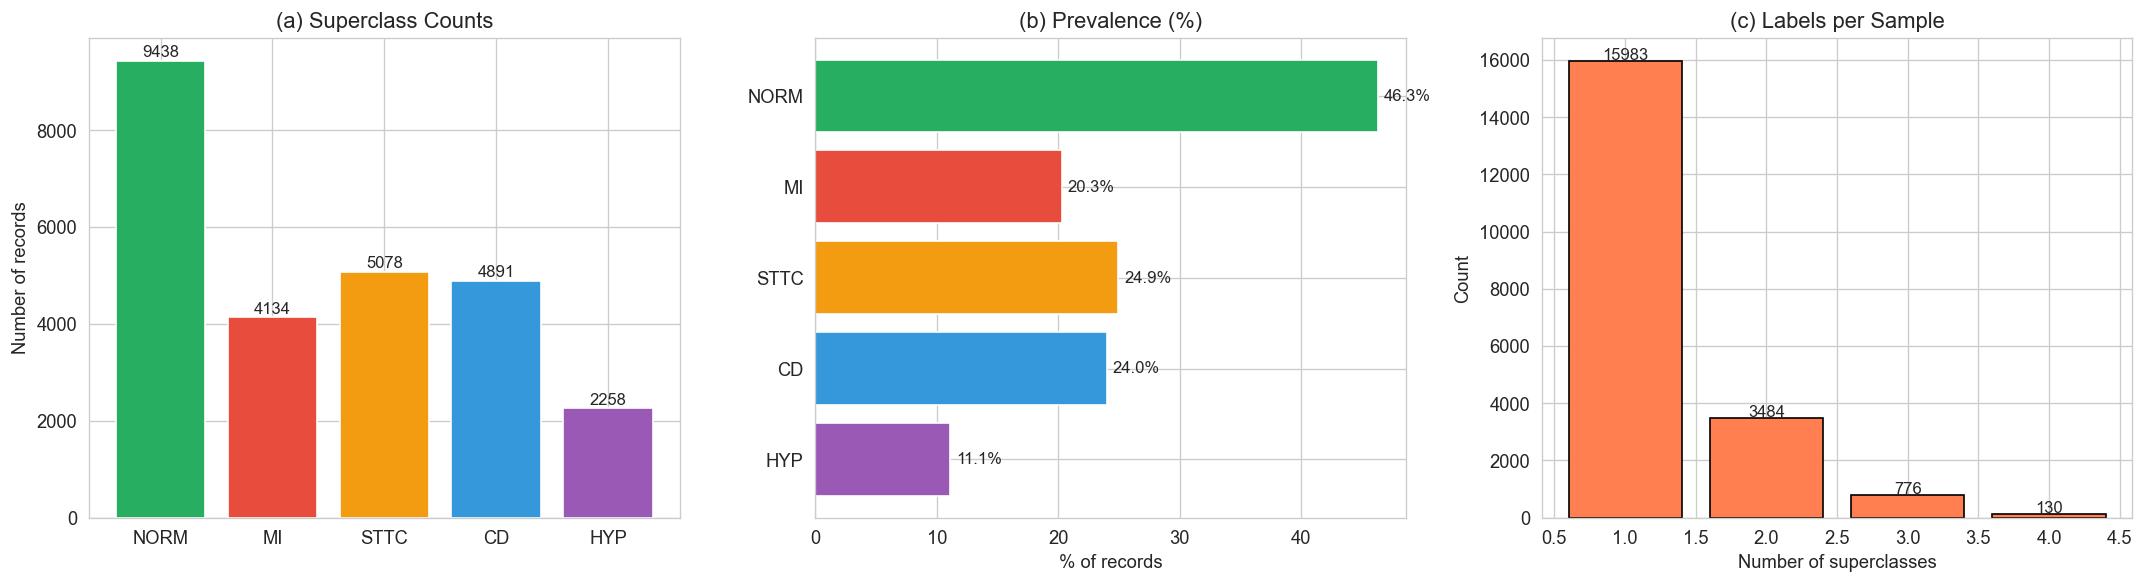


Single-label records: 15983 (78.5%)
Multi-label records : 4390 (21.5%)


In [17]:
# ── Visualise class imbalance ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Absolute counts
colors = ["#27ae60", "#e74c3c", "#f39c12", "#3498db", "#9b59b6"]
bars = axes[0].bar(SUPERCLASSES, counts, color=colors)
axes[0].set_title("(a) Superclass Counts")
axes[0].set_ylabel("Number of records")
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 str(int(c)), ha="center", fontsize=10)

# (b) Prevalence (% of all diagnostic records)
axes[1].barh(SUPERCLASSES[::-1], (counts / total * 100)[::-1],
             color=colors[::-1])
axes[1].set_title("(b) Prevalence (%)")
axes[1].set_xlabel("% of records")
for i, pct in enumerate((counts / total * 100)[::-1]):
    axes[1].text(pct + 0.5, i, f"{pct:.1f}%", va="center", fontsize=10)

# (c) Labels per sample
n_labels = labels_diag.sum(axis=1)
label_counts = Counter(n_labels.astype(int))
x_vals = sorted(label_counts.keys())
y_vals = [label_counts[x] for x in x_vals]
axes[2].bar(x_vals, y_vals, color="coral", edgecolor="k")
axes[2].set_title("(c) Labels per Sample")
axes[2].set_xlabel("Number of superclasses")
axes[2].set_ylabel("Count")
for x, y in zip(x_vals, y_vals):
    axes[2].text(x, y + 50, str(y), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSingle-label records: {(n_labels == 1).sum()} ({(n_labels == 1).mean()*100:.1f}%)")
print(f"Multi-label records : {(n_labels > 1).sum()} ({(n_labels > 1).mean()*100:.1f}%)")

## 5. Label Co-occurrence Analysis

Since this is a **multi-label** problem, we need to understand which conditions appear together. Strong co-occurrence patterns can affect both model learning (correlated outputs) and evaluation (multi-label metrics).

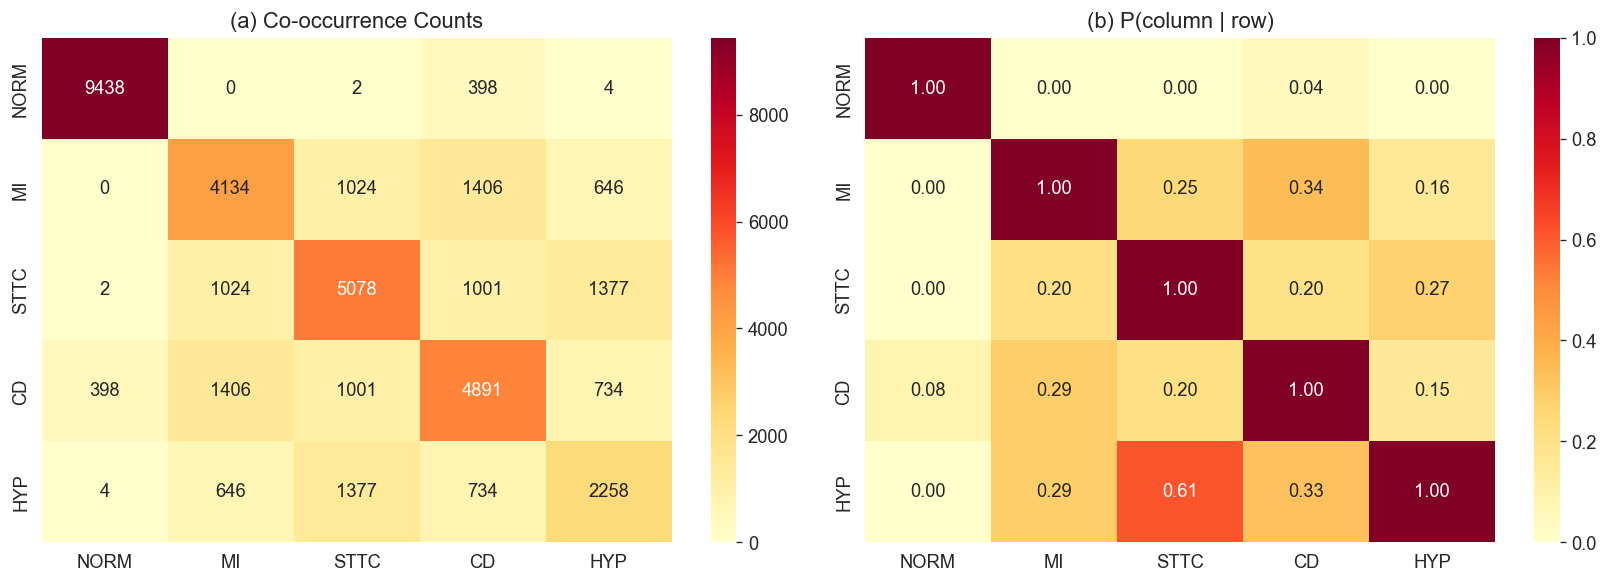

In [18]:
# ── Co-occurrence matrix ───────────────────────────────────────────
cooccur = np.zeros((len(SUPERCLASSES), len(SUPERCLASSES)), dtype=int)
for row in labels_diag:
    active = np.where(row == 1)[0]
    for i in active:
        for j in active:
            cooccur[i, j] += 1

cooccur_df = pd.DataFrame(cooccur, index=SUPERCLASSES, columns=SUPERCLASSES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute co-occurrence
sns.heatmap(cooccur_df, annot=True, fmt="d", cmap="YlOrRd", ax=axes[0])
axes[0].set_title("(a) Co-occurrence Counts")

# Normalised by row (conditional probability: P(col | row))
cooccur_norm = cooccur / cooccur.diagonal()[:, None]
np.fill_diagonal(cooccur_norm, 1.0)
cooccur_norm_df = pd.DataFrame(
    cooccur_norm, index=SUPERCLASSES, columns=SUPERCLASSES
).round(3)
sns.heatmap(cooccur_norm_df, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title("(b) P(column | row)")

plt.tight_layout()
plt.savefig("label_cooccurrence.png", dpi=150, bbox_inches="tight")
plt.show()

In [19]:
# ── Most common label combinations ─────────────────────────────────
combo_counter = Counter()
for row in labels_diag:
    active = tuple(SUPERCLASSES[i] for i in np.where(row == 1)[0])
    combo_counter[active] += 1

print("Top 15 label combinations:")
print(f"{'Combination':<35s} {'Count':>7s} {'Pct':>7s}")
print("-" * 50)
for combo, count in combo_counter.most_common(15):
    label_str = " + ".join(combo)
    pct = count / len(labels_diag) * 100
    print(f"  {label_str:<33s} {count:>6d}  {pct:>5.1f}%")

Top 15 label combinations:
Combination                           Count     Pct
--------------------------------------------------
  NORM                                9038   44.4%
  STTC                                2601   12.8%
  CD                                  2097   10.3%
  MI                                  1881    9.2%
  MI + CD                             1004    4.9%
  STTC + HYP                           747    3.7%
  STTC + CD                            495    2.4%
  MI + STTC                            438    2.1%
  NORM + CD                            394    1.9%
  HYP                                  366    1.8%
  MI + STTC + HYP                      291    1.4%
  CD + HYP                             286    1.4%
  STTC + CD + HYP                      209    1.0%
  MI + STTC + CD                       165    0.8%
  MI + STTC + CD + HYP                 130    0.6%


## 6. Demographic Analysis (Age & Sex)

In [20]:
# ── Age and sex overview ───────────────────────────────────────────
print("=== Age ===")
print(df["age"].describe().to_string())
print(f"\nMissing age: {df['age'].isna().sum()}")

print("\n=== Sex ===")
print(df["sex"].value_counts().to_string())
print(f"\n0 = male, 1 = female (PTB-XL convention)")

=== Age ===
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000

Missing age: 0

=== Sex ===
sex
0    11354
1    10445

0 = male, 1 = female (PTB-XL convention)


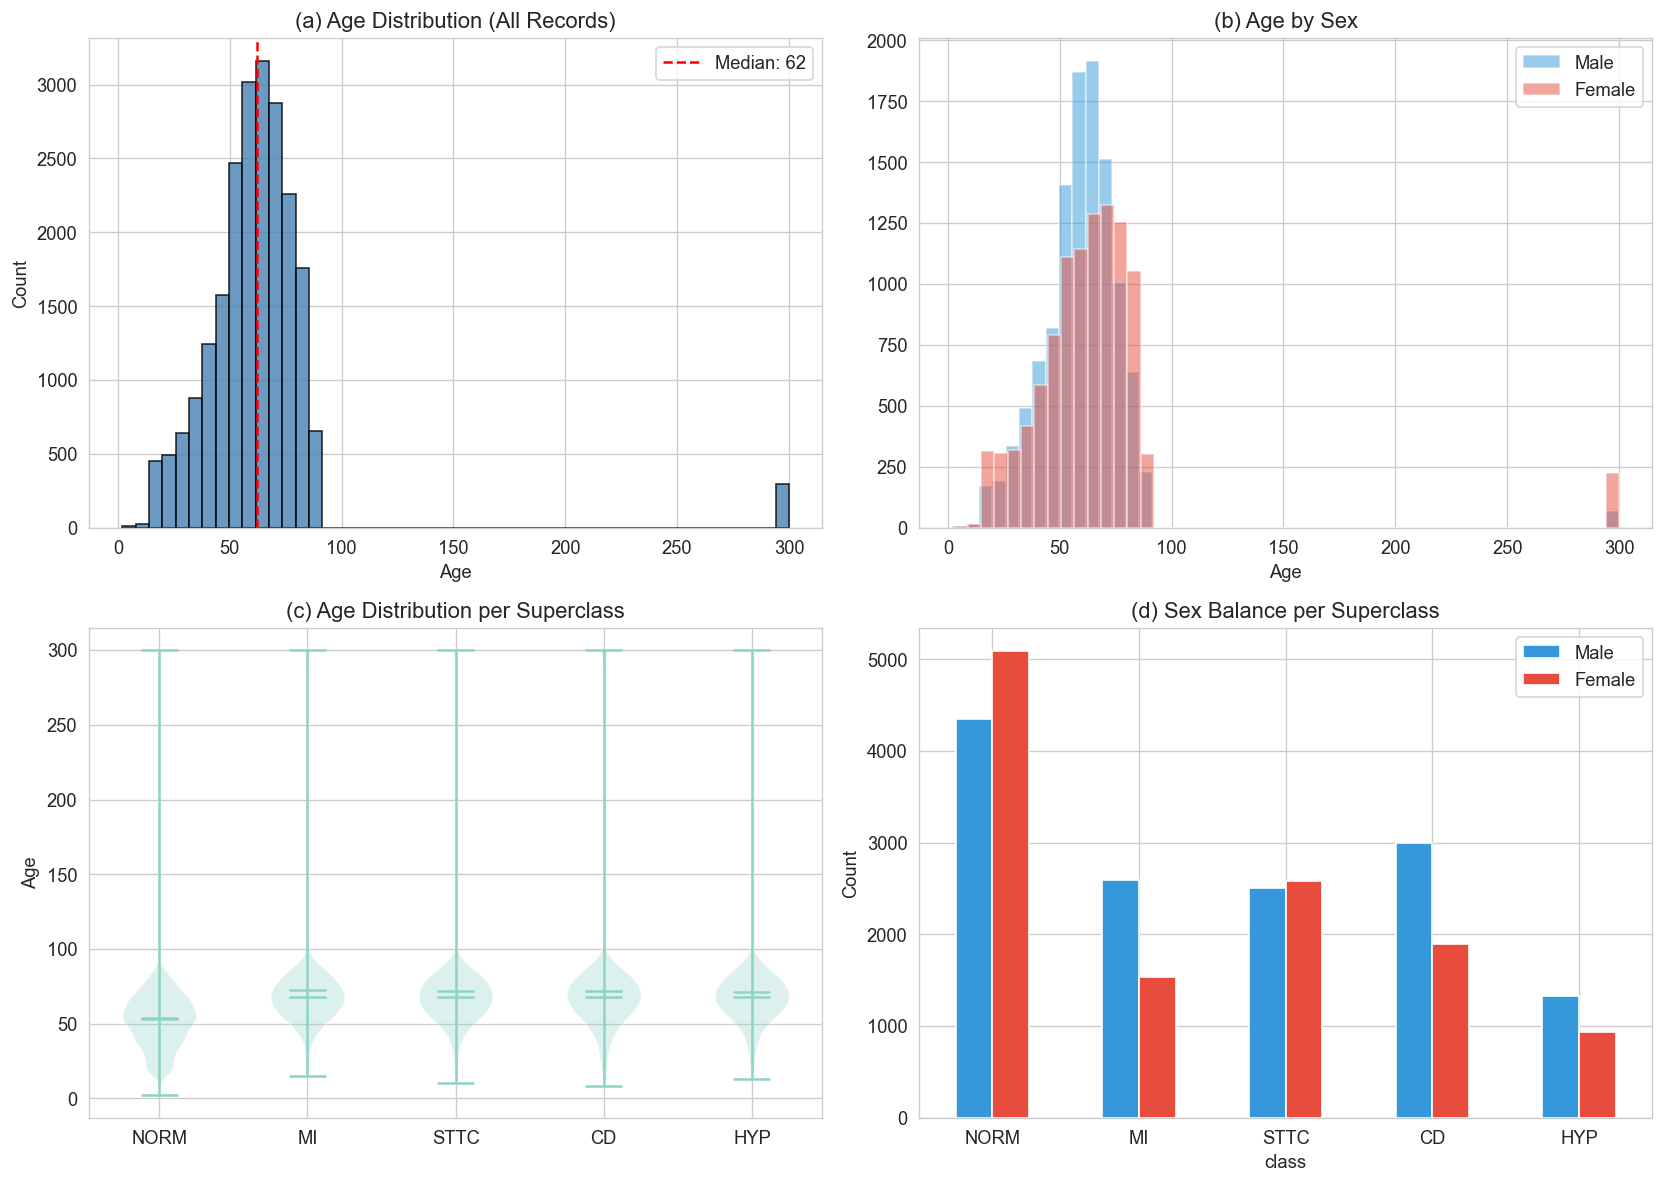

In [21]:
# ── Age distribution overall and per class ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Overall age distribution
axes[0, 0].hist(df["age"].dropna(), bins=50, color="steelblue",
                edgecolor="k", alpha=0.8)
axes[0, 0].axvline(df["age"].median(), color="red", linestyle="--",
                    label=f"Median: {df['age'].median():.0f}")
axes[0, 0].set_title("(a) Age Distribution (All Records)")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend()

# (b) Age distribution by sex
for sex_val, label, color in [(0, "Male", "#3498db"), (1, "Female", "#e74c3c")]:
    axes[0, 1].hist(df[df["sex"] == sex_val]["age"].dropna(), bins=50,
                    alpha=0.5, label=label, color=color)
axes[0, 1].set_title("(b) Age by Sex")
axes[0, 1].set_xlabel("Age")
axes[0, 1].legend()

# (c) Age distribution per superclass (violin)
class_ages = []
for i, sc in enumerate(SUPERCLASSES):
    ages = df_diag[df_diag[sc] == 1]["age"].dropna()
    class_ages.append(ages)

parts = axes[1, 0].violinplot(class_ages, positions=range(len(SUPERCLASSES)),
                               showmeans=True, showmedians=True)
axes[1, 0].set_xticks(range(len(SUPERCLASSES)))
axes[1, 0].set_xticklabels(SUPERCLASSES)
axes[1, 0].set_title("(c) Age Distribution per Superclass")
axes[1, 0].set_ylabel("Age")

# (d) Sex balance per superclass
sex_by_class = []
for sc in SUPERCLASSES:
    subset = df_diag[df_diag[sc] == 1]
    n_male = (subset["sex"] == 0).sum()
    n_female = (subset["sex"] == 1).sum()
    sex_by_class.append({"class": sc, "Male": n_male, "Female": n_female})
sex_df = pd.DataFrame(sex_by_class).set_index("class")
sex_df.plot(kind="bar", ax=axes[1, 1], color=["#3498db", "#e74c3c"])
axes[1, 1].set_title("(d) Sex Balance per Superclass")
axes[1, 1].set_ylabel("Count")
axes[1, 1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("demographics.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
# ── Per-class demographic statistics ───────────────────────────────
print(f"{'Class':>6s}  {'N':>6s}  {'Age mean':>9s}  {'Age std':>8s}  "
      f"{'% Male':>7s}  {'% Female':>8s}")
print("-" * 55)
for sc in SUPERCLASSES:
    subset = df_diag[df_diag[sc] == 1]
    age_mean = subset["age"].mean()
    age_std = subset["age"].std()
    pct_male = (subset["sex"] == 0).mean() * 100
    pct_female = (subset["sex"] == 1).mean() * 100
    print(f"  {sc:>5s}  {len(subset):>5d}  {age_mean:>8.1f}  {age_std:>7.1f}  "
          f"{pct_male:>6.1f}%  {pct_female:>7.1f}%")

 Class       N   Age mean   Age std   % Male  % Female
-------------------------------------------------------
   NORM   9438      52.8     22.3    46.1%     53.9%
     MI   4134      72.4     37.9    62.8%     37.2%
   STTC   5078      72.0     38.7    49.2%     50.8%
     CD   4891      72.1     42.1    61.2%     38.8%
    HYP   2258      71.4     37.0    58.5%     41.5%


## 7. Signal-Level Exploration

We load a subset of actual ECG waveforms to examine signal quality, amplitude ranges, and per-lead statistics. This informs our normalisation strategy.

In [23]:
# ── Load a random subset of signals for exploration ────────────────
# We sample 2000 records to keep this fast
np.random.seed(42)
SAMPLE_N = 2000
sample_indices = np.random.choice(len(df_diag), size=SAMPLE_N, replace=False)
sample_df = df_diag.iloc[sample_indices]

SAMPLING_RATE = 100
LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

signals = []
for _, row in sample_df.iterrows():
    fpath = os.path.join(DATA_DIR, row["filename_lr"])
    record = wfdb.rdrecord(fpath)
    signals.append(record.p_signal)

X_sample = np.array(signals, dtype=np.float32)
print(f"Loaded {X_sample.shape[0]} signals, shape: {X_sample.shape}")

Loaded 2000 signals, shape: (2000, 1000, 12)


In [24]:
# ── Check for NaN / Inf / zeros in signals ─────────────────────────
n_nan = np.isnan(X_sample).any(axis=(1, 2)).sum()
n_inf = np.isinf(X_sample).any(axis=(1, 2)).sum()
n_allzero = (X_sample.sum(axis=(1, 2)) == 0).sum()

print(f"Records with NaN values  : {n_nan} / {len(X_sample)}")
print(f"Records with Inf values  : {n_inf} / {len(X_sample)}")
print(f"Records that are all-zero: {n_allzero} / {len(X_sample)}")

if n_nan > 0:
    nan_per_lead = np.isnan(X_sample).any(axis=1).sum(axis=0)
    print("\nNaN counts per lead:")
    for i, name in enumerate(LEAD_NAMES):
        print(f"  {name}: {nan_per_lead[i]}")

Records with NaN values  : 0 / 2000
Records with Inf values  : 0 / 2000
Records that are all-zero: 0 / 2000


In [25]:
# ── Per-lead amplitude statistics ──────────────────────────────────
lead_stats = pd.DataFrame({
    "lead": LEAD_NAMES,
    "mean": X_sample.mean(axis=(0, 1)),
    "std": X_sample.std(axis=(0, 1)),
    "min": X_sample.min(axis=(0, 1)),
    "max": X_sample.max(axis=(0, 1)),
    "median": np.median(X_sample, axis=(0, 1)),
    "p01": np.percentile(X_sample, 1, axis=(0, 1)),
    "p99": np.percentile(X_sample, 99, axis=(0, 1)),
})

print("Per-lead signal statistics (mV):")
lead_stats.round(4)

Per-lead signal statistics (mV):


,lead,mean,std,min,max,median,p01,p99
0,I,-0.0012,0.1528,-1.679,3.334,-0.025,-0.280,0.696
1,II,-0.0014,0.1603,-1.783,3.422,-0.022,-0.353,0.636
2,III,-0.0002,0.1568,-3.513,3.880,0.005,-0.568,0.416
3,aVR,0.0013,0.1356,-2.461,1.667,0.025,-0.613,0.244
4,aVL,-0.0004,0.1325,-2.169,3.145,-0.013,-0.288,0.568
5,aVF,-0.0008,0.1388,-2.405,3.651,-0.007,-0.392,0.454
6,V1,0.0003,0.2236,-8.975,6.978,0.021,-0.962,0.502
7,V2,-0.0008,0.3363,-11.102,5.692,0.000,-1.398,0.804
8,V3,-0.0015,0.3246,-7.863,8.505,-0.020,-1.146,0.949
9,V4,-0.0012,0.2967,-11.198,8.383,-0.034,-0.760,1.152


C:\Users\edvar\AppData\Local\Temp\ipykernel_18616\1383223927.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(lead_data, labels=LEAD_NAMES, showfliers=False, patch_artist=True)


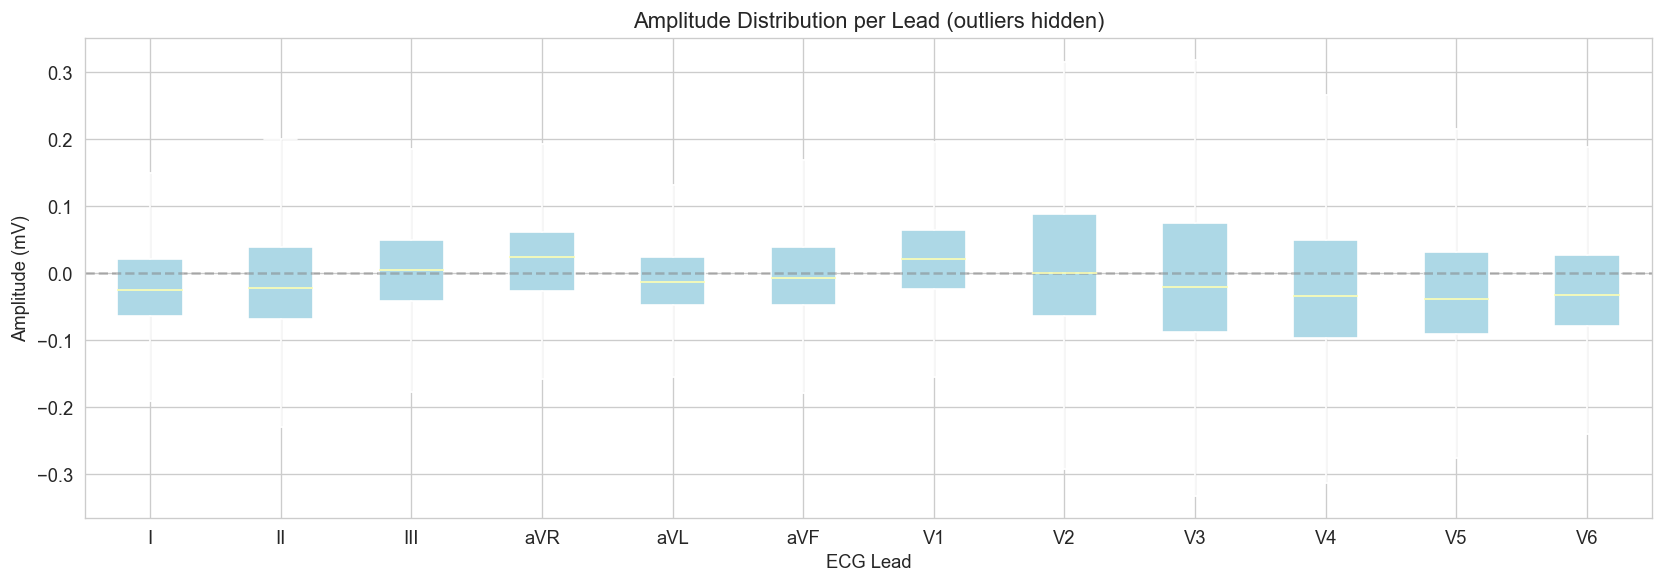

In [26]:
# ── Per-lead amplitude distributions (box plots) ───────────────────
# Flatten each lead across all samples and timesteps
fig, ax = plt.subplots(figsize=(14, 5))

lead_data = [X_sample[:, :, i].flatten() for i in range(12)]
bp = ax.boxplot(lead_data, labels=LEAD_NAMES, showfliers=False, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightblue")

ax.set_title("Amplitude Distribution per Lead (outliers hidden)")
ax.set_ylabel("Amplitude (mV)")
ax.set_xlabel("ECG Lead")
ax.axhline(0, color="grey", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("lead_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

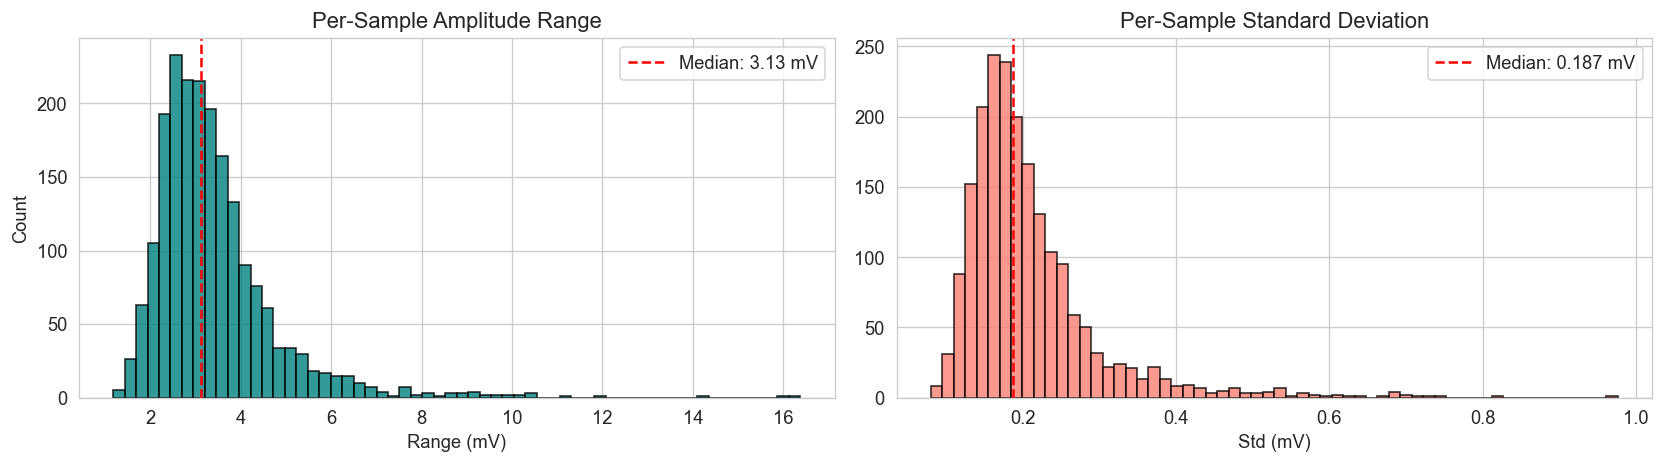

Signals with very high amplitude range (>99th pctile): 20
Signals with very low amplitude range  (<1st pctile) : 20


In [27]:
# ── Per-sample amplitude range (max - min across all leads) ────────
sample_ranges = X_sample.max(axis=(1, 2)) - X_sample.min(axis=(1, 2))
sample_stds = X_sample.std(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_ranges, bins=60, color="teal", edgecolor="k", alpha=0.8)
axes[0].axvline(np.median(sample_ranges), color="red", linestyle="--",
                label=f"Median: {np.median(sample_ranges):.2f} mV")
axes[0].set_title("Per-Sample Amplitude Range")
axes[0].set_xlabel("Range (mV)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(sample_stds, bins=60, color="salmon", edgecolor="k", alpha=0.8)
axes[1].axvline(np.median(sample_stds), color="red", linestyle="--",
                label=f"Median: {np.median(sample_stds):.3f} mV")
axes[1].set_title("Per-Sample Standard Deviation")
axes[1].set_xlabel("Std (mV)")
axes[1].legend()

plt.tight_layout()
plt.savefig("signal_ranges.png", dpi=150, bbox_inches="tight")
plt.show()

# Flag potential outlier signals
high_range = sample_ranges > np.percentile(sample_ranges, 99)
low_range = sample_ranges < np.percentile(sample_ranges, 1)
print(f"Signals with very high amplitude range (>99th pctile): {high_range.sum()}")
print(f"Signals with very low amplitude range  (<1st pctile) : {low_range.sum()}")

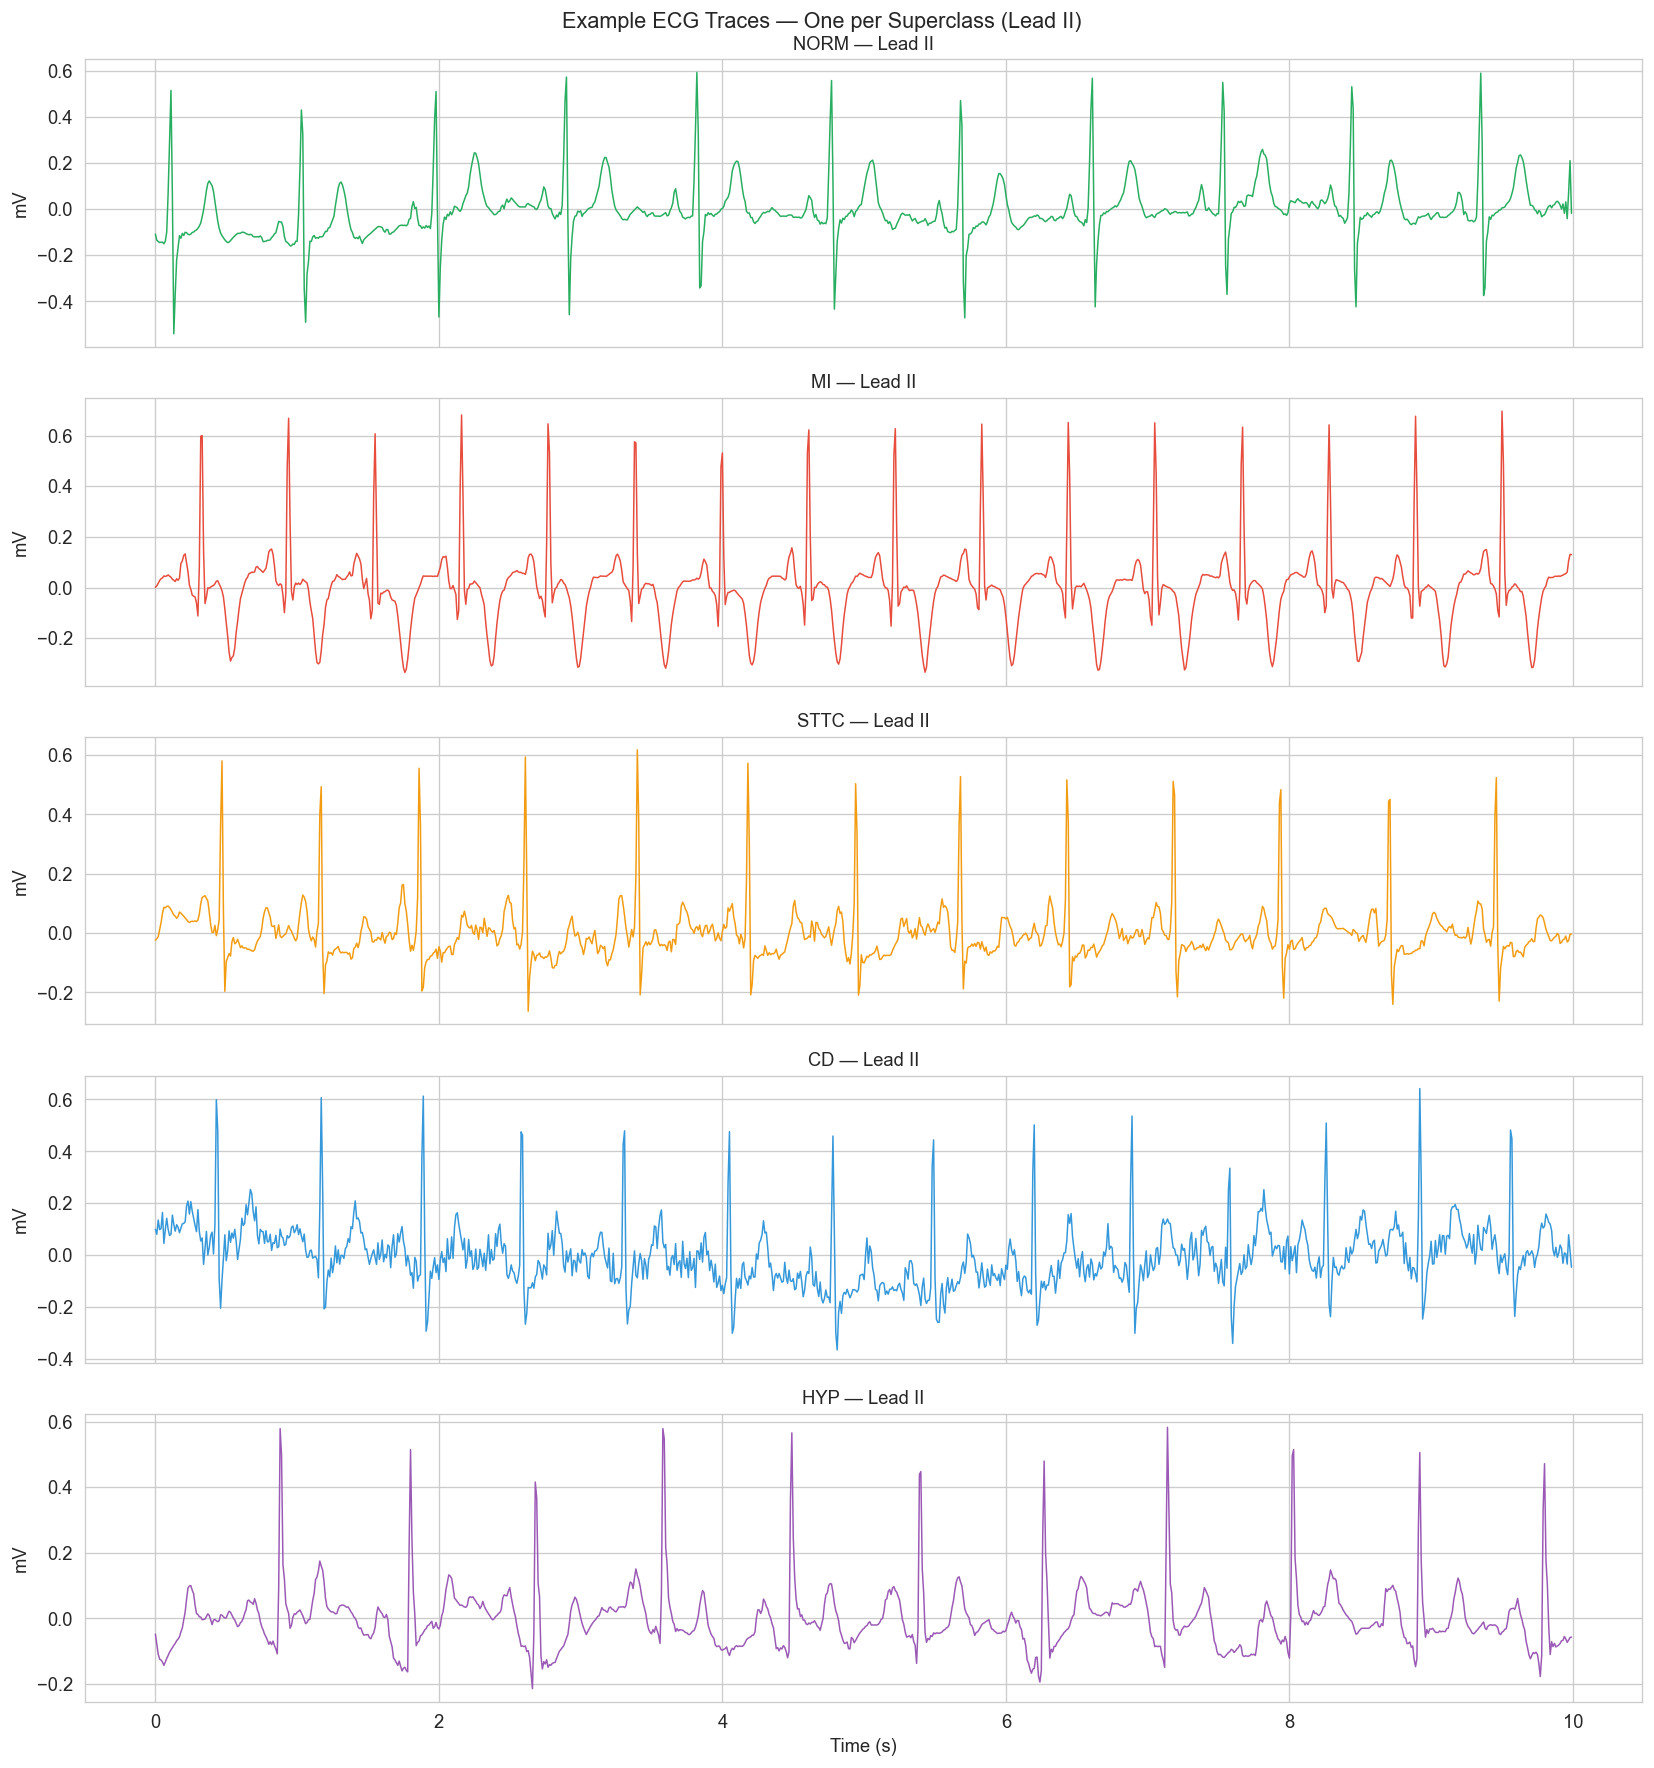

In [28]:
# ── Example signals: one per superclass ────────────────────────────
sample_labels = labels_diag[sample_indices]
time = np.arange(X_sample.shape[1]) / SAMPLING_RATE

fig, axes = plt.subplots(len(SUPERCLASSES), 1, figsize=(14, 3 * len(SUPERCLASSES)),
                         sharex=True)

for i, (sc, ax) in enumerate(zip(SUPERCLASSES, axes)):
    # Find a sample that has ONLY this superclass (pure case)
    candidates = np.where(
        (sample_labels[:, i] == 1) &
        (sample_labels.sum(axis=1) == 1)
    )[0]
    if len(candidates) == 0:
        candidates = np.where(sample_labels[:, i] == 1)[0]

    idx = candidates[0]
    # Plot Lead II (standard clinical lead)
    ax.plot(time, X_sample[idx, :, 1], color=colors[i], linewidth=0.9)
    ax.set_title(f"{sc} — Lead II", fontsize=11)
    ax.set_ylabel("mV")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Example ECG Traces — One per Superclass (Lead II)", fontsize=13)
plt.tight_layout()
plt.savefig("example_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Fold Balance Analysis

PTB-XL provides a `strat_fold` column for 10-fold stratified splitting. We verify that the class distribution is consistent across folds, especially between train (1–8), validation (9), and test (10).

In [29]:
# ── Class distribution per fold ────────────────────────────────────
fold_stats = []
for fold in range(1, 11):
    mask = df_diag["strat_fold"] == fold
    fold_labels = labels_diag[mask.values]
    n = mask.sum()
    row = {"fold": fold, "n_samples": n}
    for i, sc in enumerate(SUPERCLASSES):
        row[f"{sc}_pct"] = fold_labels[:, i].mean() * 100
    fold_stats.append(row)

fold_df = pd.DataFrame(fold_stats).set_index("fold")
print("Class prevalence (%) per fold:")
fold_df.round(1)

Class prevalence (%) per fold:


,n_samples,NORM_pct,MI_pct,STTC_pct,CD_pct,HYP_pct
fold,,,,,,
1,2034,45.9,20.6,25.4,23.6,10.9
2,2039,47.2,19.7,24.7,23.7,11.4
3,2066,47.5,19.7,24.3,23.6,11.1
4,2022,45.5,20.5,25.3,24.4,11.4
5,2029,45.9,21.0,25.1,24.4,11.0
6,2014,45.7,21.0,25.3,24.5,11.2
7,2043,47.3,19.9,24.9,23.3,11.0
8,2042,45.3,20.1,24.6,24.0,11.4
9,2034,46.3,20.3,25.1,24.3,10.6


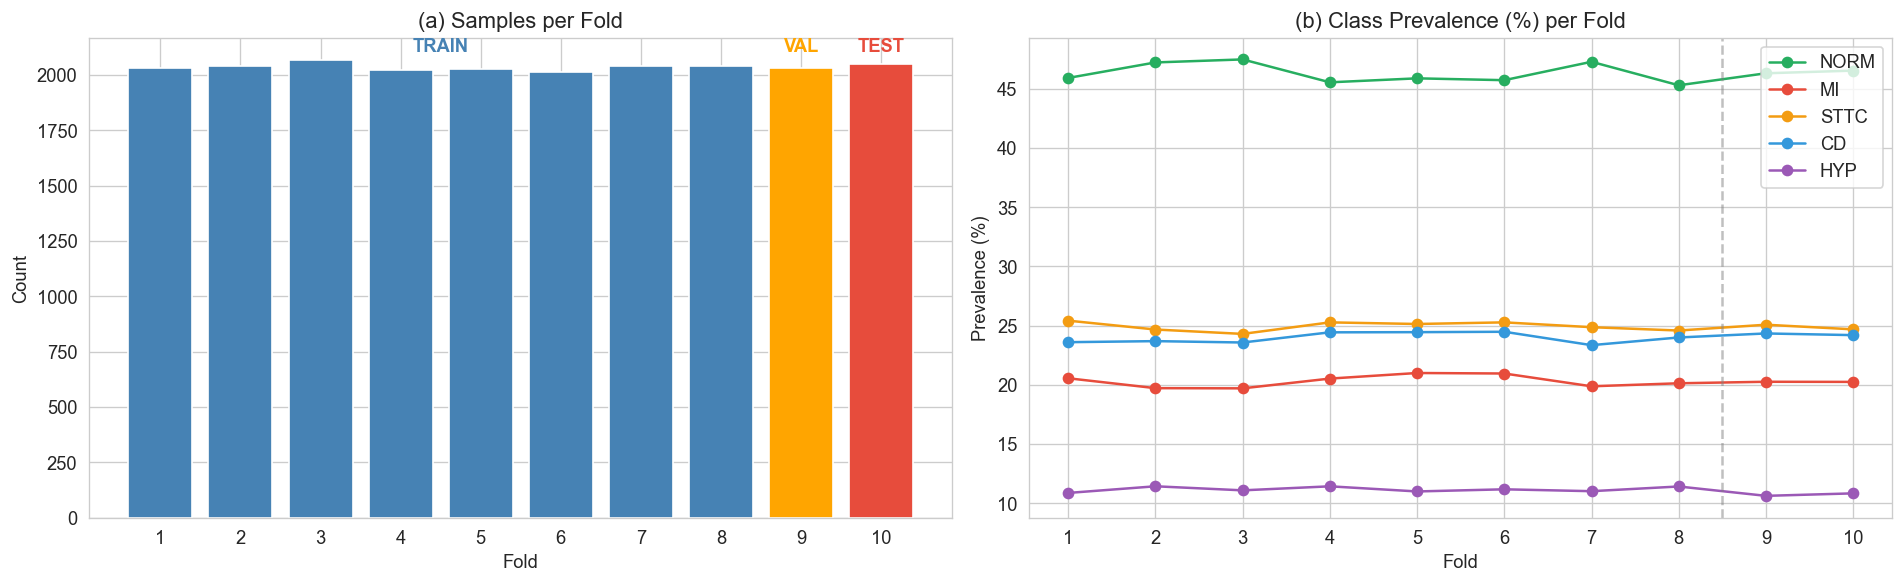

In [30]:
# ── Visualise fold balance ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Samples per fold
fold_colors = ["steelblue"] * 8 + ["orange", "#e74c3c"]
axes[0].bar(range(1, 11), fold_df["n_samples"], color=fold_colors)
axes[0].set_title("(a) Samples per Fold")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Count")
axes[0].set_xticks(range(1, 11))
# Annotate train/val/test
axes[0].text(4.5, fold_df["n_samples"].max() * 1.02, "TRAIN",
             ha="center", fontsize=11, color="steelblue", fontweight="bold")
axes[0].text(9, fold_df["n_samples"].max() * 1.02, "VAL",
             ha="center", fontsize=11, color="orange", fontweight="bold")
axes[0].text(10, fold_df["n_samples"].max() * 1.02, "TEST",
             ha="center", fontsize=11, color="#e74c3c", fontweight="bold")

# (b) Class prevalence per fold (line plot)
for i, sc in enumerate(SUPERCLASSES):
    axes[1].plot(range(1, 11), fold_df[f"{sc}_pct"], marker="o",
                label=sc, color=colors[i])
axes[1].axvline(8.5, color="grey", linestyle="--", alpha=0.5)
axes[1].set_title("(b) Class Prevalence (%) per Fold")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Prevalence (%)")
axes[1].set_xticks(range(1, 11))
axes[1].legend()

plt.tight_layout()
plt.savefig("fold_balance.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
# ── Train / Val / Test split summary ───────────────────────────────
splits = {"Train (1-8)": df_diag["strat_fold"] <= 8,
          "Val (9)": df_diag["strat_fold"] == 9,
          "Test (10)": df_diag["strat_fold"] == 10}

print(f"{'Split':<15s} {'N':>6s}", end="")
for sc in SUPERCLASSES:
    print(f"  {sc:>6s}", end="")
print()
print("-" * 55)

for name, mask in splits.items():
    n = mask.sum()
    print(f"{name:<15s} {n:>5d}", end="")
    split_labels = labels_diag[mask.values]
    for i in range(len(SUPERCLASSES)):
        pct = split_labels[:, i].mean() * 100
        print(f"  {pct:>5.1f}%", end="")
    print()

Split                N    NORM      MI    STTC      CD     HYP
-------------------------------------------------------
Train (1-8)     16289   46.3%   20.3%   24.9%   23.9%   11.2%
Val (9)          2034   46.3%   20.3%   25.1%   24.3%   10.6%
Test (10)        2050   46.5%   20.2%   24.7%   24.2%   10.8%


## 9. Recording Metadata Exploration

In [32]:
# ── Device, site, and validation status ────────────────────────────
if "device" in df.columns:
    print("Recording devices:")
    print(df["device"].value_counts().to_string())
    print()

if "recording_date" in df.columns:
    df["rec_date"] = pd.to_datetime(df["recording_date"], errors="coerce")
    print(f"Recording date range: {df['rec_date'].min()} to {df['rec_date'].max()}")

if "validated_by_human" in df.columns:
    print(f"\nValidated by human: {df['validated_by_human'].sum()} / {len(df)}")

if "initial_autogenerated" in df.columns:
    print(f"Auto-generated labels: {df['initial_autogenerated'].sum()} / {len(df)}")

Recording devices:
device
CS100    3    6140
CS-12         4048
AT-6 C 5.5    3950
CS-12   E     2878
AT-6     6    2273
AT-60    3     966
AT-6 C 5.8     824
AT-6 C         514
AT-6 C 5.0      80
AT-6 C 5.3      67
AT-6 C 5.6      59

Recording date range: 1984-11-09 09:17:34 to 2001-06-11 16:43:01

Validated by human: 16056 / 21799


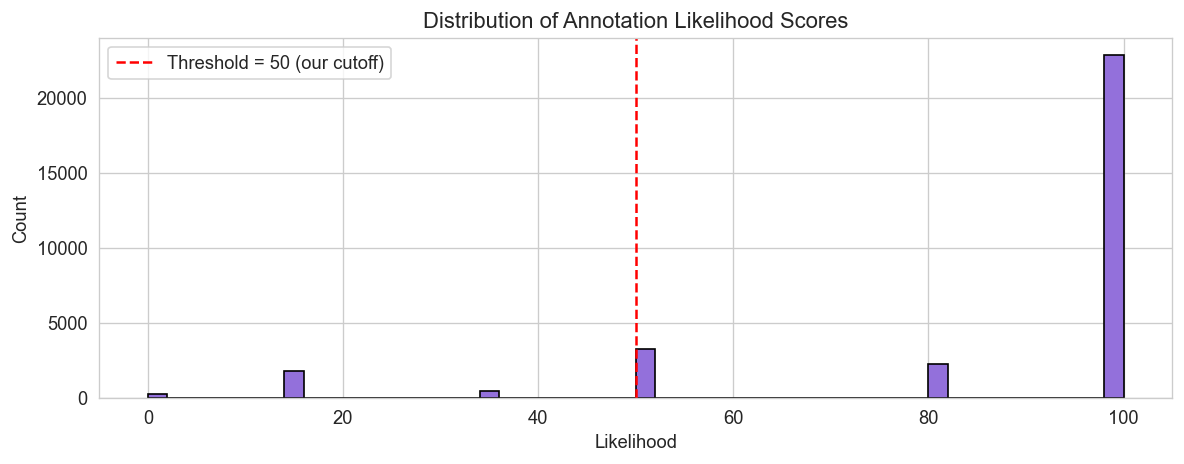


Annotations below threshold 50: 2386 / 30721 (7.8%)
Annotations at 100: 22870 (74.4%)


In [33]:
# ── Annotation likelihood distribution ─────────────────────────────
# How confident are the annotations? Plot likelihood values.
all_likelihoods = []
for scp_dict in df["scp_codes"]:
    for code, likelihood in scp_dict.items():
        if code in code_to_superclass:
            all_likelihoods.append(likelihood)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_likelihoods, bins=50, color="mediumpurple", edgecolor="k")
ax.axvline(50, color="red", linestyle="--",
           label="Threshold = 50 (our cutoff)")
ax.set_title("Distribution of Annotation Likelihood Scores")
ax.set_xlabel("Likelihood")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("likelihood_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

below_threshold = sum(1 for l in all_likelihoods if l < 50)
print(f"\nAnnotations below threshold 50: {below_threshold} / {len(all_likelihoods)} "
      f"({below_threshold/len(all_likelihoods)*100:.1f}%)")
print(f"Annotations at 100: {sum(1 for l in all_likelihoods if l == 100)} "
      f"({sum(1 for l in all_likelihoods if l == 100)/len(all_likelihoods)*100:.1f}%)")

## 10. Inter-Lead Correlation

The 12 ECG leads are derived from the same cardiac electrical activity, so they are highly correlated. Understanding this helps us decide whether to use all 12 leads or whether dimensionality reduction might be useful.

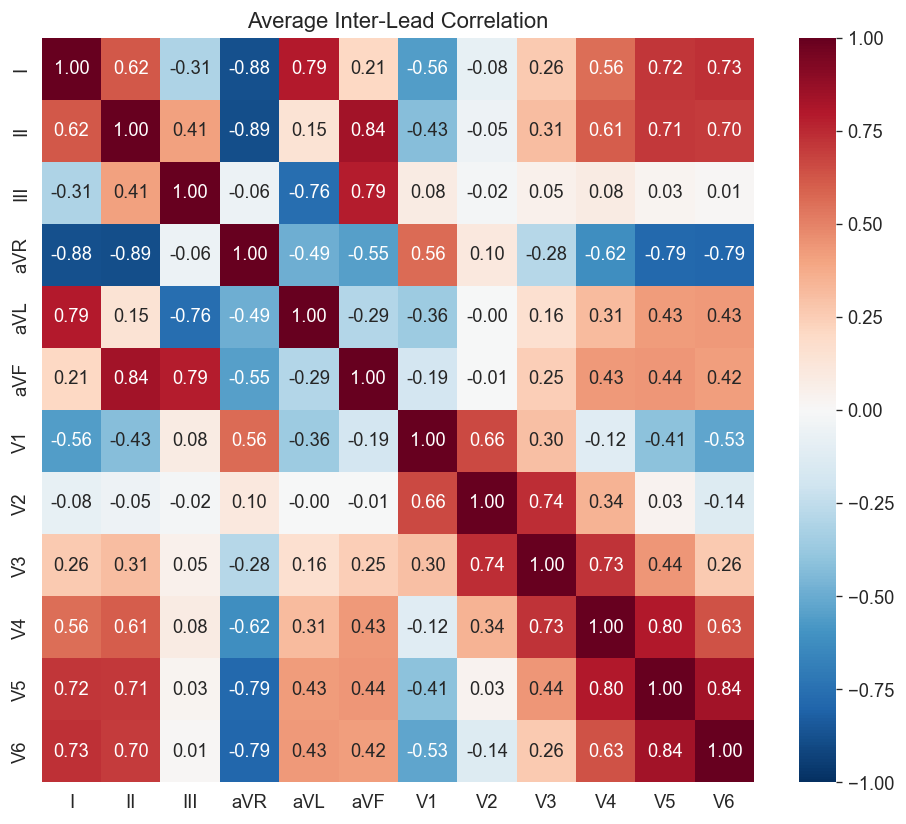

In [34]:
# ── Average inter-lead correlation across all samples ──────────────
# Compute correlation matrix per sample, then average
corr_sum = np.zeros((12, 12))
for i in range(len(X_sample)):
    corr_sum += np.corrcoef(X_sample[i].T)
avg_corr = corr_sum / len(X_sample)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(avg_corr, xticklabels=LEAD_NAMES, yticklabels=LEAD_NAMES,
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            vmin=-1, vmax=1)
ax.set_title("Average Inter-Lead Correlation")
plt.tight_layout()
plt.savefig("lead_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Summary of Key Findings

In [35]:
print("""
========================================================================
  EDA SUMMARY — Key Findings for Modelling Decisions
========================================================================

1. CLASS IMBALANCE
   - NORM is by far the most common class.
   - HYP is the least common.
   → Use class weights in the loss function or focal loss.
   → Report per-class metrics (not just overall accuracy).

2. MULTI-LABEL NATURE
   - A significant portion of records have 2+ superclasses.
   - STTC + MI is a common co-occurrence (clinically expected).
   → Use sigmoid + BCE, NOT softmax + CCE.
   → Evaluate with multi-label metrics (macro F1, sample accuracy).

3. DEMOGRAPHICS
   - Age distribution varies by condition (e.g., MI skews older).
   - Sex ratios differ per class.
   → Be aware of potential demographic bias; report disaggregated.

4. SIGNAL QUALITY
   → Check NaN/zero findings above. If present, handle before training.
   → Per-lead amplitude ranges differ substantially — Z-score per lead.

5. FOLD BALANCE
   - The stratified folds maintain consistent class proportions.
   → Safe to use the standard 1-8/9/10 train/val/test split.

6. LEAD CORRELATIONS
   - Limb leads (I, II, III) are strongly correlated (mathematically).
   - Precordial leads show spatial progression.
   → All 12 leads carry useful info; keep all for the model.
""")


  EDA SUMMARY — Key Findings for Modelling Decisions

1. CLASS IMBALANCE
   - NORM is by far the most common class.
   - HYP is the least common.
   → Use class weights in the loss function or focal loss.
   → Report per-class metrics (not just overall accuracy).

2. MULTI-LABEL NATURE
   - A significant portion of records have 2+ superclasses.
   - STTC + MI is a common co-occurrence (clinically expected).
   → Use sigmoid + BCE, NOT softmax + CCE.
   → Evaluate with multi-label metrics (macro F1, sample accuracy).

3. DEMOGRAPHICS
   - Age distribution varies by condition (e.g., MI skews older).
   - Sex ratios differ per class.
   → Be aware of potential demographic bias; report disaggregated.

4. SIGNAL QUALITY
   → Check NaN/zero findings above. If present, handle before training.
   → Per-lead amplitude ranges differ substantially — Z-score per lead.

5. FOLD BALANCE
   - The stratified folds maintain consistent class proportions.
   → Safe to use the standard 1-8/9/10 train/val